In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tsfel
import os

# Set style visualisasi plot
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

In [2]:
# 1. Membaca Dataset Mentah CH4 (365 Hari)
raw_path = '../data/csv/timeseries/CH4_gresik_timeseries.csv'
df_raw = pd.read_csv(raw_path)
df_raw['date'] = pd.to_datetime(df_raw['date'])
df_raw = df_raw.sort_values('date').reset_index(drop=True)

total_rows = len(df_raw)
nan_awal = df_raw['CH4'].isna().sum()
valid_awal = df_raw['CH4'].notna().sum()
print(f"Total Baris Observasi   : {total_rows} hari")
print(f"Jumlah Data Valid Awal  : {valid_awal} hari ({valid_awal/total_rows*100:.2f}%)")
print(f"Jumlah Missing (NaN)    : {nan_awal} hari ({nan_awal/total_rows*100:.2f}%)")

# 2. Deteksi Outlier Menggunakan Metode Interquartile Range (IQR) pada Data Valid
q1 = df_raw['CH4'].quantile(0.25)
q3 = df_raw['CH4'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

is_outlier = (df_raw['CH4'] < lower_bound) | (df_raw['CH4'] > upper_bound)
jumlah_outlier = is_outlier.sum()
print(f"\nKuartil 1 (Q1)           : {q1:.6f} ppb")
print(f"Kuartil 3 (Q3)           : {q3:.6f} ppb")
print(f"IQR (Q3 - Q1)            : {iqr:.6f} ppb")
print(f"Batas Bawah (Lower Bound): {lower_bound:.6f} ppb")
print(f"Batas Atas (Upper Bound) : {upper_bound:.6f} ppb")
print(f"Jumlah Outlier Terdeteksi: {jumlah_outlier} hari")

# Menampilkan rincian tanggal & nilai outlier yang terdeteksi
df_outliers = df_raw[is_outlier][['date', 'CH4']].copy()
df_outliers['date'] = df_outliers['date'].dt.strftime('%Y-%m-%d')
print("\nDaftar Tanggal & Nilai Outlier Terdeteksi:")
print(df_outliers.to_string(index=False))

# 3. Pengosongan Nilai Outlier Menjadi NaN & Imputasi Polynomial Interpolation
df_prep = df_raw.copy()
df_prep.loc[is_outlier, 'CH4'] = np.nan
nan_setelah_outlier = df_prep['CH4'].isna().sum()
print(f"\nJumlah NaN Setelah Outlier Dikosongkan: {nan_setelah_outlier} hari ({nan_setelah_outlier/total_rows*100:.2f}%)")

df_clean = df_prep.copy()
df_clean['CH4_clean'] = df_clean['CH4'].interpolate(method='polynomial', order=2, limit_direction='both').bfill().ffill()
nan_akhir = df_clean['CH4_clean'].isna().sum()
print(f"Jumlah NaN Setelah Imputasi Akhir      : {nan_akhir} hari (100% Clean!)")

# Simpan dataset bersih ke file CSV
clean_csv_path = '../data/csv/clean/CH4_clean.csv'
os.makedirs(os.path.dirname(clean_csv_path), exist_ok=True)
df_clean[['date', 'CH4_clean']].rename(columns={'CH4_clean': 'CH4'}).to_csv(clean_csv_path, index=False)
print(f"SUCCESS: Dataset bersih disimpan ke '{clean_csv_path}'")

Total Baris Observasi   : 365 hari
Jumlah Data Valid Awal  : 20 hari (5.48%)
Jumlah Missing (NaN)    : 345 hari (94.52%)

Kuartil 1 (Q1)           : 1879.265198 ppb
Kuartil 3 (Q3)           : 1905.920166 ppb
IQR (Q3 - Q1)            : 26.654968 ppb
Batas Bawah (Lower Bound): 1839.282745 ppb
Batas Atas (Upper Bound) : 1945.902618 ppb
Jumlah Outlier Terdeteksi: 1 hari

Daftar Tanggal & Nilai Outlier Terdeteksi:
      date        CH4
2026-06-07 1821.64209

Jumlah NaN Setelah Outlier Dikosongkan: 346 hari (94.79%)
Jumlah NaN Setelah Imputasi Akhir      : 0 hari (100% Clean!)
SUCCESS: Dataset bersih disimpan ke '../data/csv/clean/CH4_clean.csv'


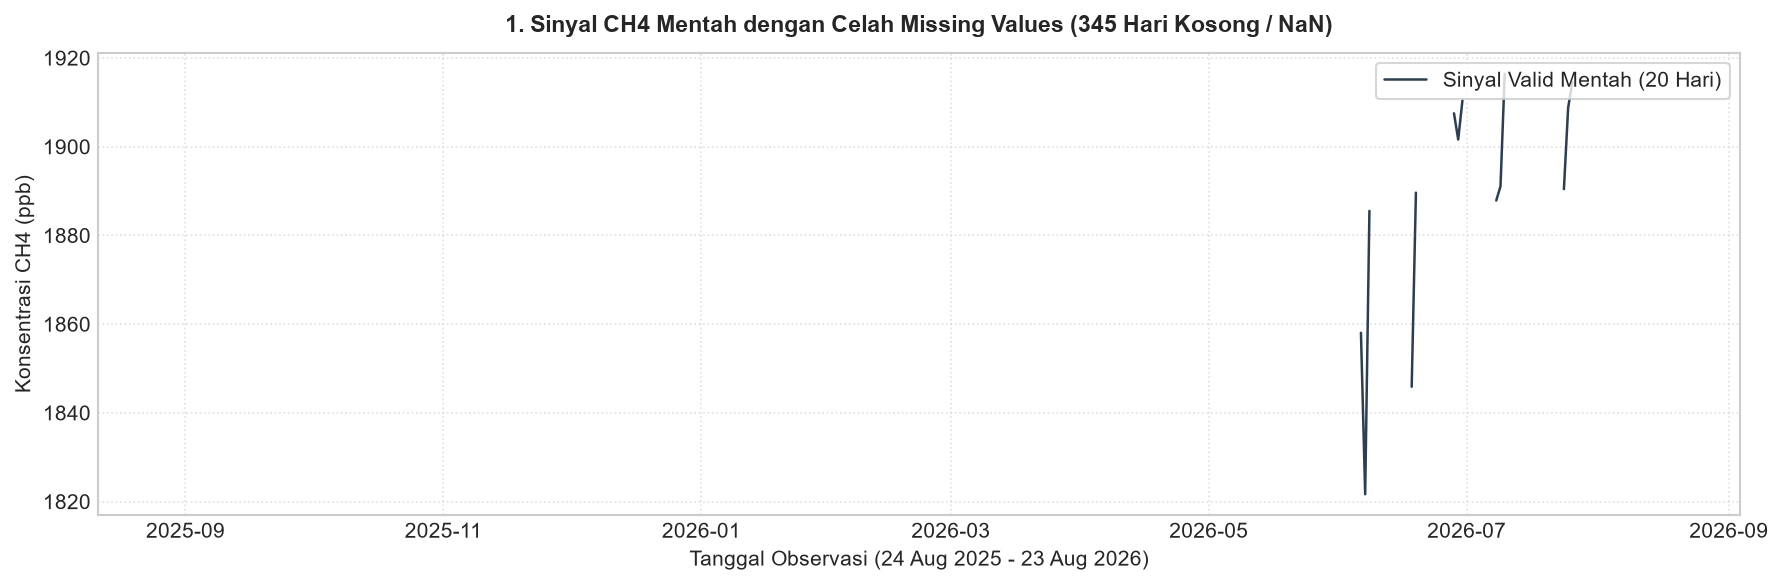

In [3]:
# Grafik 1: Missing Values (Data Mentah dengan Celah Kosong / NaN)
fig, ax = plt.subplots(figsize=(12, 4), dpi=150)
ax.plot(df_raw['date'], df_raw['CH4'], color='#2c3e50', linewidth=1.2, label=f'Sinyal Valid Mentah ({valid_awal} Hari)')
ax.set_title(f'1. Sinyal CH4 Mentah dengan Celah Missing Values ({nan_awal} Hari Kosong / NaN)', fontsize=11, fontweight='bold', pad=10)
ax.set_xlabel('Tanggal Observasi (24 Aug 2025 - 23 Aug 2026)', fontsize=10)
ax.set_ylabel('Konsentrasi CH4 (ppb)', fontsize=10)
ax.legend(loc='upper right', frameon=True)
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

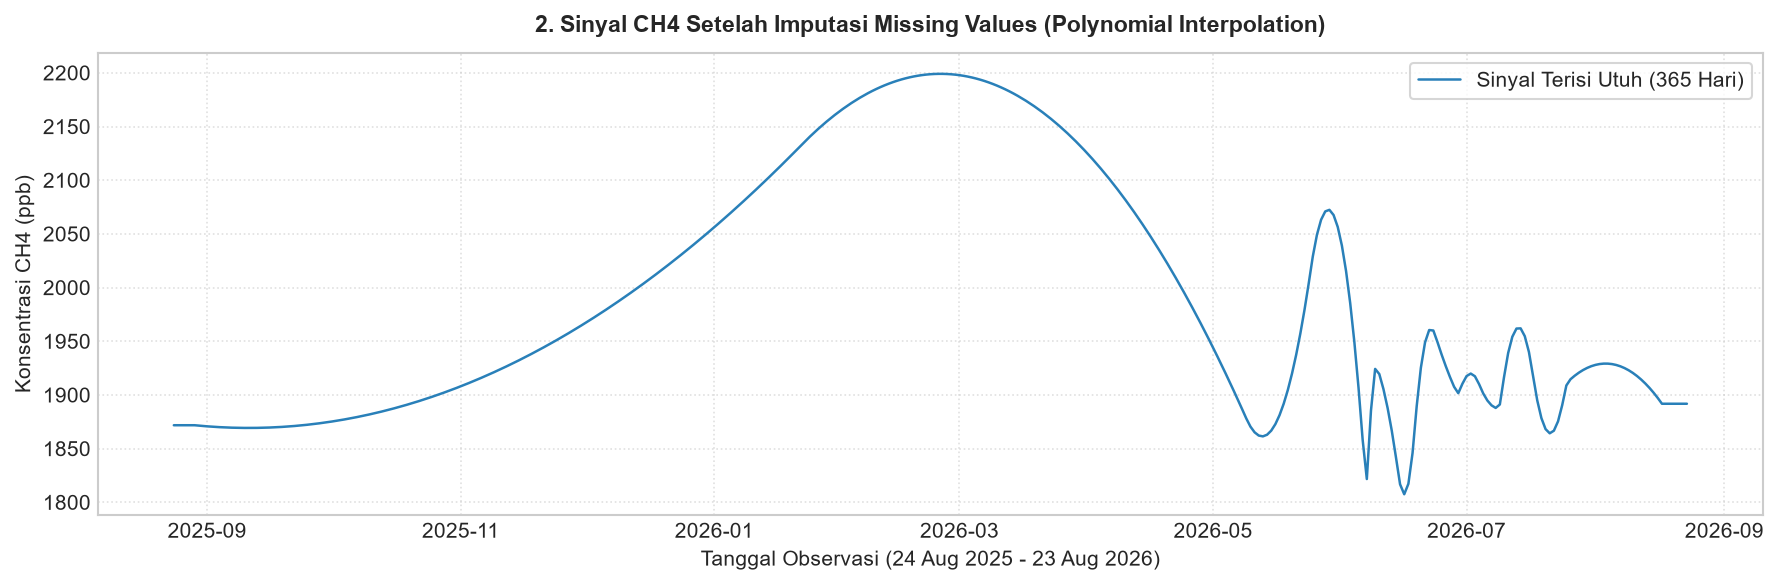

In [4]:
# Grafik 2: Sinyal Setelah Missing Values Diimputasi (Sebelum Cleaning Outlier)
df_raw_imputed = df_raw.copy()
df_raw_imputed['CH4_imputed'] = df_raw_imputed['CH4'].interpolate(method='polynomial', order=2, limit_direction='both').bfill().ffill()

fig, ax = plt.subplots(figsize=(12, 4), dpi=150)
ax.plot(df_raw_imputed['date'], df_raw_imputed['CH4_imputed'], color='#2980b9', linewidth=1.2, label='Sinyal Terisi Utuh (365 Hari)')
ax.set_title('2. Sinyal CH4 Setelah Imputasi Missing Values (Polynomial Interpolation)', fontsize=11, fontweight='bold', pad=10)
ax.set_xlabel('Tanggal Observasi (24 Aug 2025 - 23 Aug 2026)', fontsize=10)
ax.set_ylabel('Konsentrasi CH4 (ppb)', fontsize=10)
ax.legend(loc='upper right', frameon=True)
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

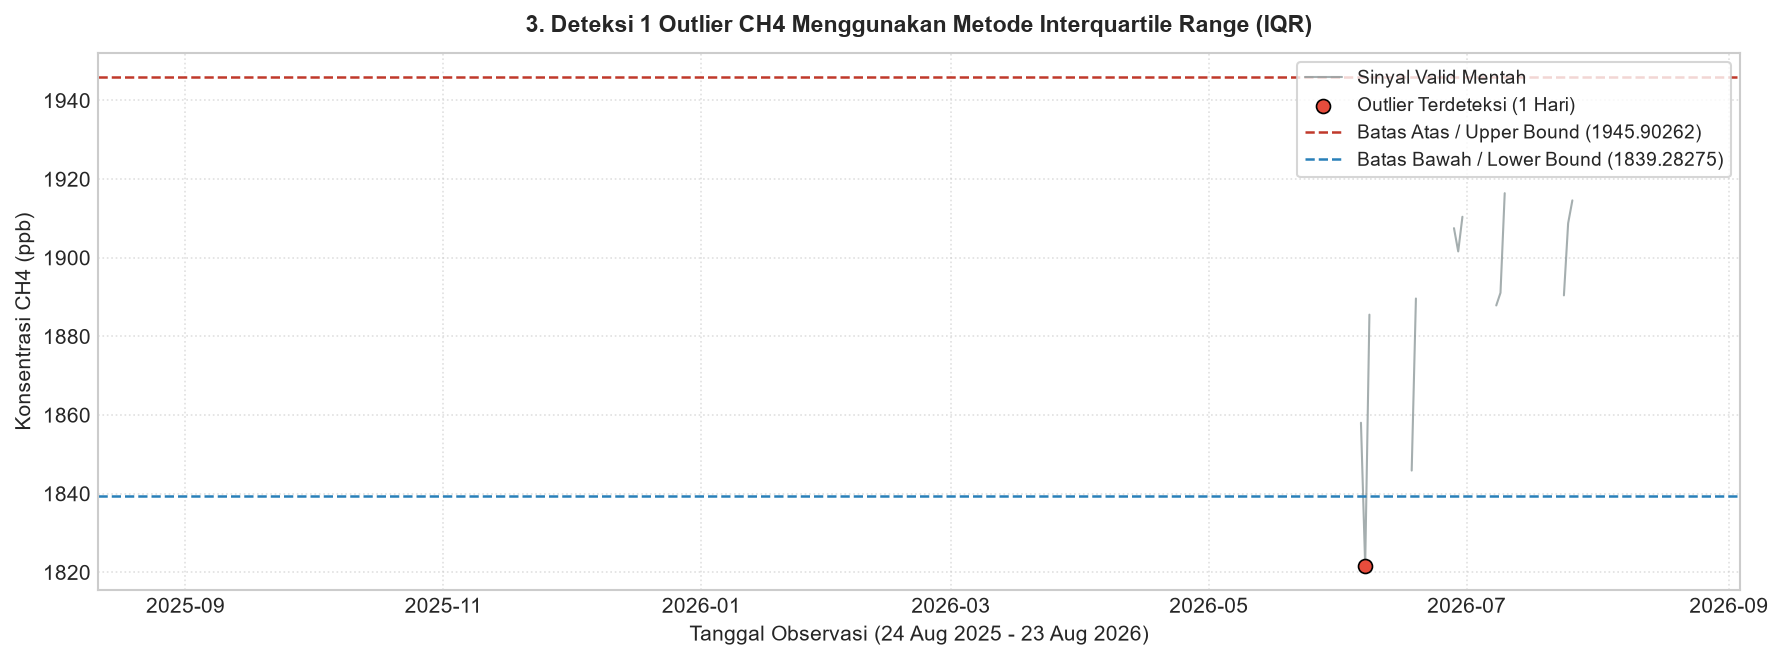

In [5]:
# Grafik 3: Deteksi Outlier Menggunakan Metode IQR
outliers_plot = df_raw[is_outlier]

fig, ax = plt.subplots(figsize=(12, 4.5), dpi=150)
ax.plot(df_raw['date'], df_raw['CH4'], color='#7f8c8d', linewidth=1.0, alpha=0.7, label='Sinyal Valid Mentah')
ax.scatter(outliers_plot['date'], outliers_plot['CH4'], color='#e74c3c', s=45, zorder=5, marker='o', edgecolor='black', linewidth=0.8, label=f'Outlier Terdeteksi ({jumlah_outlier} Hari)')
ax.axhline(upper_bound, color='#c0392b', linestyle='--', linewidth=1.2, label=f'Batas Atas / Upper Bound ({upper_bound:.5f})')
ax.axhline(lower_bound, color='#2980b9', linestyle='--', linewidth=1.2, label=f'Batas Bawah / Lower Bound ({lower_bound:.5f})')
ax.set_title(f'3. Deteksi {jumlah_outlier} Outlier CH4 Menggunakan Metode Interquartile Range (IQR)', fontsize=11, fontweight='bold', pad=10)
ax.set_xlabel('Tanggal Observasi (24 Aug 2025 - 23 Aug 2026)', fontsize=10)
ax.set_ylabel('Konsentrasi CH4 (ppb)', fontsize=10)
ax.legend(loc='upper right', frameon=True, fontsize=9)
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

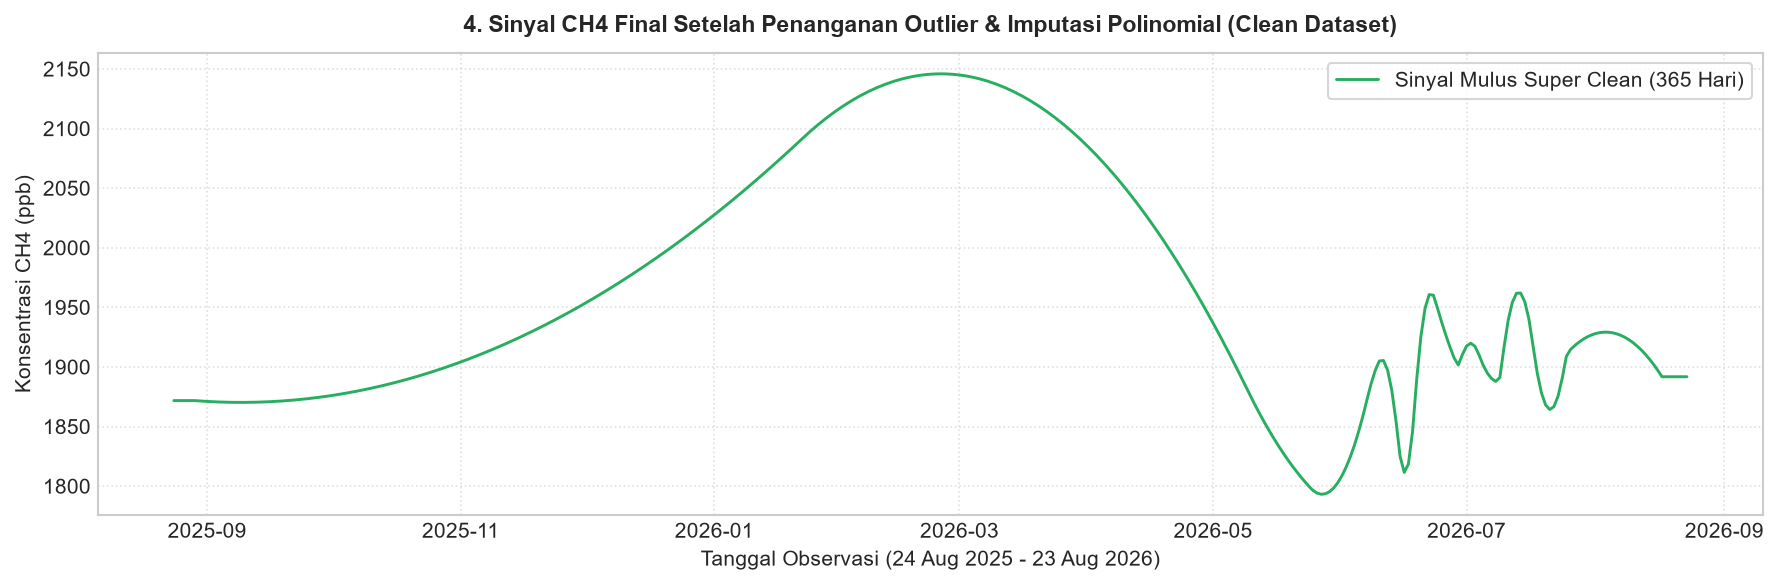

In [6]:
# Grafik 4: Sinyal CH4 Final Setelah Outlier Dibersihkan & Diimputasi
fig, ax = plt.subplots(figsize=(12, 4), dpi=150)
ax.plot(df_clean['date'], df_clean['CH4_clean'], color='#27ae60', linewidth=1.4, label='Sinyal Mulus Super Clean (365 Hari)')
ax.set_title('4. Sinyal CH4 Final Setelah Penanganan Outlier & Imputasi Polinomial (Clean Dataset)', fontsize=11, fontweight='bold', pad=10)
ax.set_xlabel('Tanggal Observasi (24 Aug 2025 - 23 Aug 2026)', fontsize=10)
ax.set_ylabel('Konsentrasi CH4 (ppb)', fontsize=10)
ax.legend(loc='upper right', frameon=True)
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [7]:
# 1. Daftar Resmi 68 Fitur TSFEL
FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

# 2. Memuat Konfigurasi TSFEL & Aktifkan Fitur dari FEATURE_LIST
cfg = tsfel.get_features_by_domain()
func_to_feat = {}
for domain in cfg:
    for feat_name, feat_dict in cfg[domain].items():
        func_name = feat_dict.get('function', '').replace('tsfel.', '')
        if func_name in FEATURE_LIST:
            feat_dict['use'] = 'yes'
            if 'wavelet' in func_name:
                feat_dict['parameters']['max_width'] = 2
            func_to_feat[func_name] = feat_name
        else:
            feat_dict['use'] = 'no'

# 3. Ekstraksi Fitur TSFEL Langsung dari Sinyal Clean
raw_df = tsfel.time_series_features_extractor(cfg, df_clean['CH4_clean'], fs=1, verbose=0)

# 4. Pemetaan Presisi Matriks 68 Fitur (f1_abs_energy ... f68_zero_cross)
row_dict = {}
for i, func_name in enumerate(FEATURE_LIST):
    code = f"f{i+1}"
    matching_cols = [c for c in raw_df.columns if func_name in c.lower().replace('tsfel.', '') or func_to_feat.get(func_name, '').lower() in c.lower()]
    if not matching_cols:
        feat_title = func_to_feat.get(func_name, '')
        matching_cols = [c for c in raw_df.columns if feat_title.lower() in c.lower()]
    
    val = raw_df[matching_cols[0]].values[0] if matching_cols else 0.0
    row_dict[f"{code}_{func_name}"] = val

df_68_matrix = pd.DataFrame([row_dict])
features_path = '../data/csv/features/CH4_tsfel_features.csv'
os.makedirs(os.path.dirname(features_path), exist_ok=True)
df_68_matrix.to_csv(features_path, index=False)
print(f"SUCCESS: Matriks Presisi 68 Fitur TSFEL berhasil disimpan ke '{features_path}'! (Shape: {df_68_matrix.shape})")
df_68_matrix


C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\tsfel\feature_extraction\features_utils.py:534: RuntimeWarning: invalid value encountered in divide
  rs = np.divide(r, s)


SUCCESS: Matriks Presisi 68 Fitur TSFEL berhasil disimpan ke '../data/csv/features/CH4_tsfel_features.csv'! (Shape: (1, 68))


,f1_abs_energy,f2_auc,f3_autocorr,f4_average_power,f5_calc_centroid,f6_calc_max,f7_calc_mean,f8_calc_median,f9_calc_min,f10_calc_std,...,f59_spectral_spread,f60_spectral_variation,f61_spectrogram_mean_coeff,f62_sum_abs_diff,f63_wavelet_abs_mean,f64_wavelet_energy,f65_wavelet_entropy,f66_wavelet_std,f67_wavelet_var,f68_zero_cross
0,1.410516e+09,714702.11404,50.0,3.875045e+06,181.910219,2145.879225,1963.243495,1927.874132,1793.170282,100.513702,...,0.020547,0.143538,106176.960383,1368.585788,8.152634,80.525494,-0.0,80.111733,6417.889716,0.0
